# Chapter 10 - Creating ML models to predict sequences
***

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
from torch.utils.data import TensorDataset, DataLoader, Subset
import optuna

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [2]:
from utils import *
from models import *

## Data

### Generate time series

In [3]:
# configuration
baseline = 10
slope = 0.09
amplitude = 20
noise_level = 5

# create time series
time = np.arange(4 * 365 + 1, dtype="float32")
series = baseline + trend(time, slope)
series += seasonality(time, period=365, amplitude=amplitude)
series += noise(time, noise_level, seed=42)

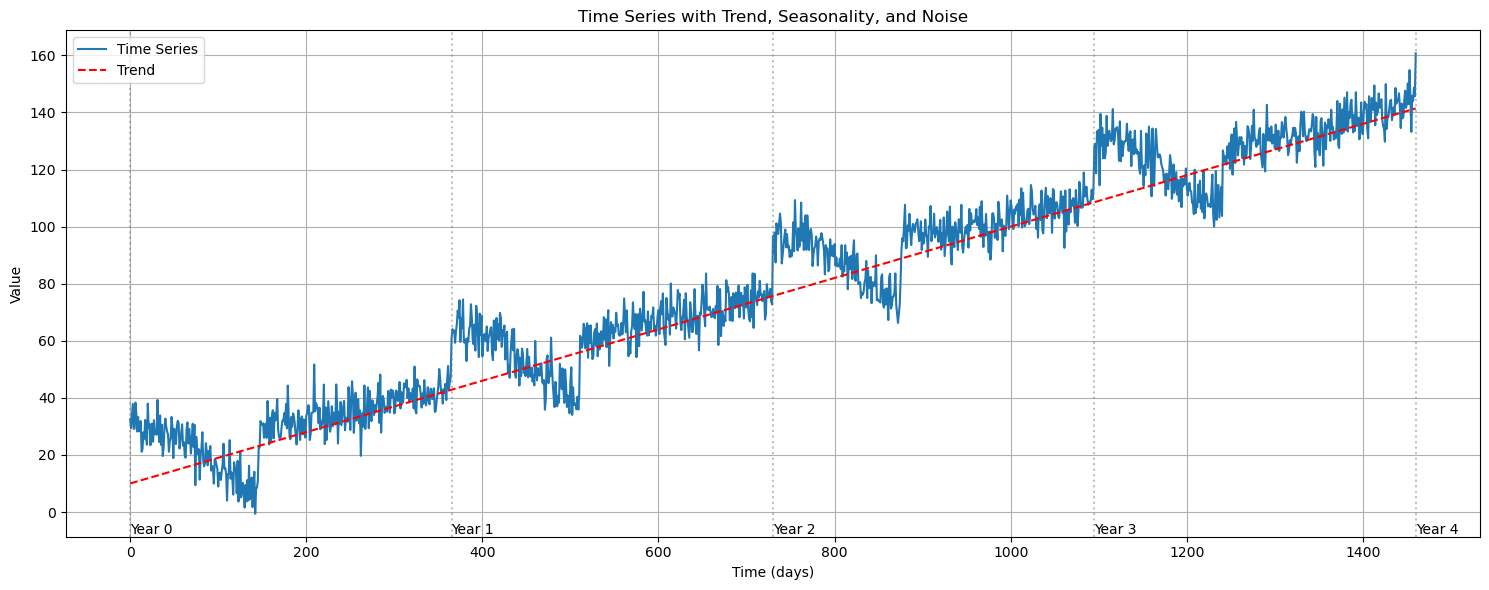

In [4]:
# Create the plot
plt.figure(figsize=(15, 6))
plt.plot(time, series, label='Time Series')

# Add trend line
trend_line = baseline + trend(time, slope)
plt.plot(time, trend_line, 'r--', label='Trend')

# Customize the plot
plt.title('Time Series with Trend, Seasonality, and Noise')
plt.xlabel('Time (days)')
plt.ylabel('Value')
plt.grid(True)
plt.legend()

# Display year markers
years = 4
for year in range(years + 1):
    plt.axvline(x=year * 365, color='gray', linestyle=':', alpha=0.5)
    plt.text(year * 365, plt.ylim()[0], f'Year {year}',
             verticalalignment='bottom')

plt.tight_layout()
plt.show()

### `DataLoader`

In [13]:
window_size = 45
batch_size = 32
train_size = 1000

# Convert the numpy series to a PyTorch tensor
series_tensor = torch.tensor(series, dtype=torch.float32)

# Create windowed dataset with 30-day windows (predicting next day)
features, targets = create_sliding_windows(
    series_tensor, 
    window_size=window_size, 
    shift=1
    )

# Create PyTorch Dataset and DataLoader
dataset = TensorDataset(features, targets)

# Calculate split indices
# Note: Since we're using windows, we need to account for the overlap
# The index 1000 in the original series will correspond to a different window index
train_size -= (window_size + 1)  # Adjust for window overlap
total_windows = len(features)
train_indices = list(range(train_size))
val_indices = list(range(train_size, total_windows))

# Create training and validation datasets using Subset
train_dataset = Subset(dataset, train_indices)
val_dataset = Subset(dataset, val_indices)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# Print information about the splits
print(f"Original series length: {len(series)}")
print(f"Total number of windows: {total_windows}")
print(f"Training windows: {len(train_dataset)}")
print(f"Validation windows: {len(val_dataset)}")

# Show example batch from each
print("\nExample Training Batch:")
train_features, train_targets = next(iter(train_loader))
print(f"Batch shape - Features: {train_features.shape}, Targets: {train_targets.shape}")

print("\nExample Validation Batch:")
val_features, val_targets = next(iter(val_loader))
print(f"Batch shape - Features: {val_features.shape}, Targets: {val_targets.shape}")

Original series length: 1461
Total number of windows: 1417
Training windows: 954
Validation windows: 463

Example Training Batch:
Batch shape - Features: torch.Size([32, 44]), Targets: torch.Size([32, 1])

Example Validation Batch:
Batch shape - Features: torch.Size([32, 44]), Targets: torch.Size([32, 1])


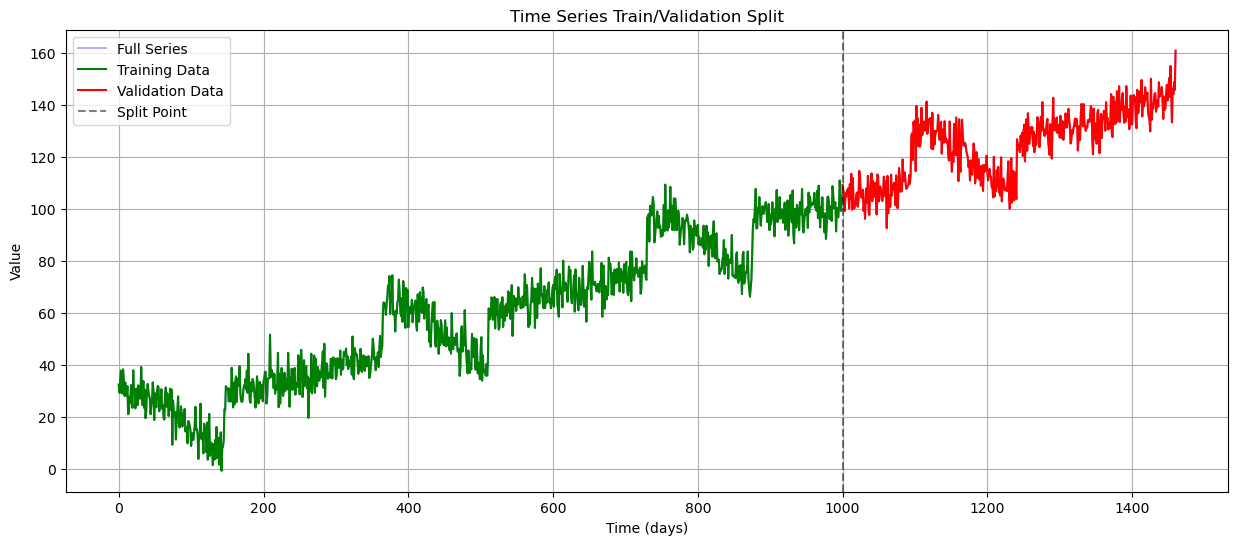

In [14]:
# Visualize the split point
plt.figure(figsize=(15, 6))
plt.plot(range(len(series)), series, 'b-', label='Full Series', alpha=0.3)
plt.plot(range(1000), series[:1000], 'g-', label='Training Data')
plt.plot(range(1000, len(series)), series[1000:], 'r-', label='Validation Data')
plt.axvline(x=1000, color='k', linestyle='--', alpha=0.5, label='Split Point')
plt.title('Time Series Train/Validation Split')
plt.xlabel('Time (days)')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()

In [22]:
features, target = train_dataset[0]
print("First window:")
print(f"Features shape: {features.shape}")
print(f"Features: {features.numpy()}")
print(f"Target: {target.item()}\n")

First window:
Features shape: torch.Size([44])
Features: [32.48357  29.395714 33.40659  37.858486 29.14184  29.20528  38.32948
 34.322147 28.183279 33.283253 28.287313 28.303862 31.864614 21.104889
 22.057411 27.875519 25.622026 32.25094  26.127428 23.588236 37.95459
 29.468477 30.900469 23.39905  27.755371 30.980967 24.615065 32.186863
 27.23822  28.710733 27.083256 39.27061  29.854065 24.540276 33.84384
 23.524242 30.565239 19.610209 22.650501 30.153908 32.735462 29.768927
 28.198286 27.131008]
Target: 21.099538803100586



## Models
### Multilayer Perceptron

Epoch [100 / 100], Train Loss: 34.9323, Val Loss: 44.4364


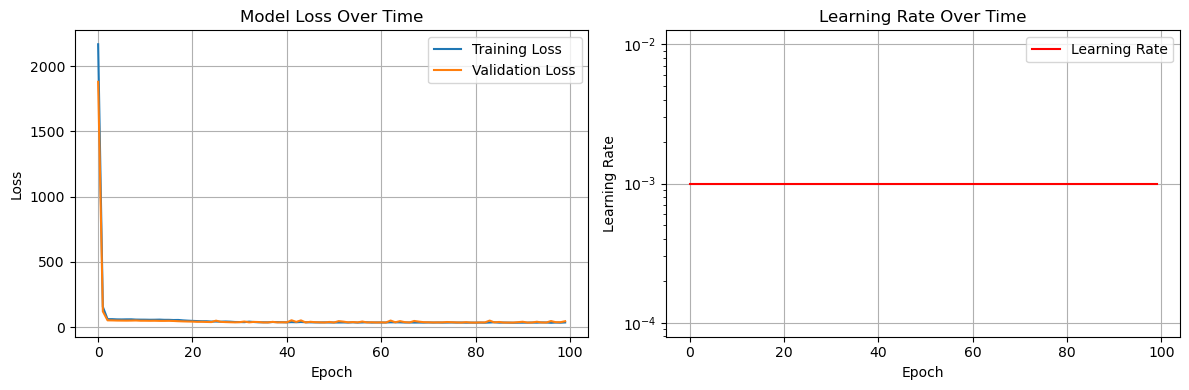

In [10]:
# Initialize model, loss function, and optimizer
model = TimeSeriesMLP(window_size - 1)
model.to(device)

# Set up training
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

# Train the model
train_losses, val_losses, learning_rates = train(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    epochs=100
)

# Analyse training
plot_training(train_losses, val_losses, learning_rates)

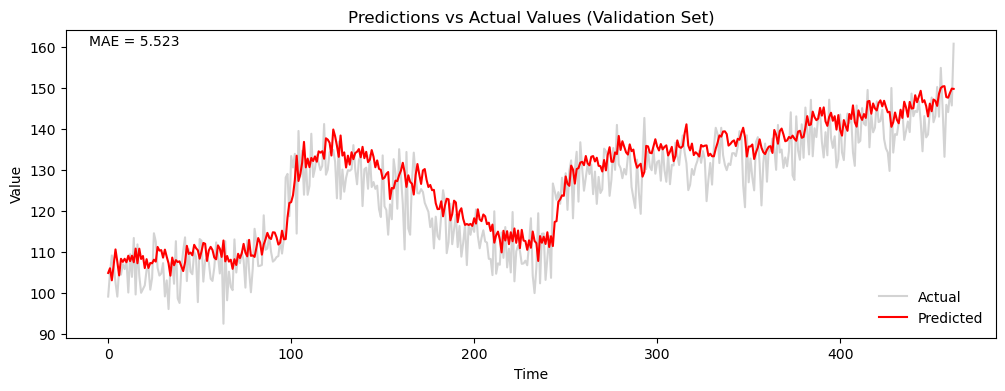

In [19]:
# predict
predictions, targets = predict(model, val_loader)
plot_prediction(predictions, targets)

#### Learning rate

Epoch [100 / 1000], Train Loss: 37.6857, Val Loss: 42.0159
Epoch [200 / 1000], Train Loss: 35.4952, Val Loss: 41.1207
Epoch [300 / 1000], Train Loss: 30.9775, Val Loss: 32.8385
Epoch [400 / 1000], Train Loss: 30.0828, Val Loss: 33.1562
Epoch [500 / 1000], Train Loss: 29.9867, Val Loss: 32.8255
Epoch [600 / 1000], Train Loss: 29.2640, Val Loss: 33.0473
Epoch [700 / 1000], Train Loss: 29.1833, Val Loss: 33.4543
Epoch [800 / 1000], Train Loss: 28.9852, Val Loss: 32.9863
Epoch [900 / 1000], Train Loss: 28.9480, Val Loss: 32.9561
Epoch [1000 / 1000], Train Loss: 29.0150, Val Loss: 32.9439


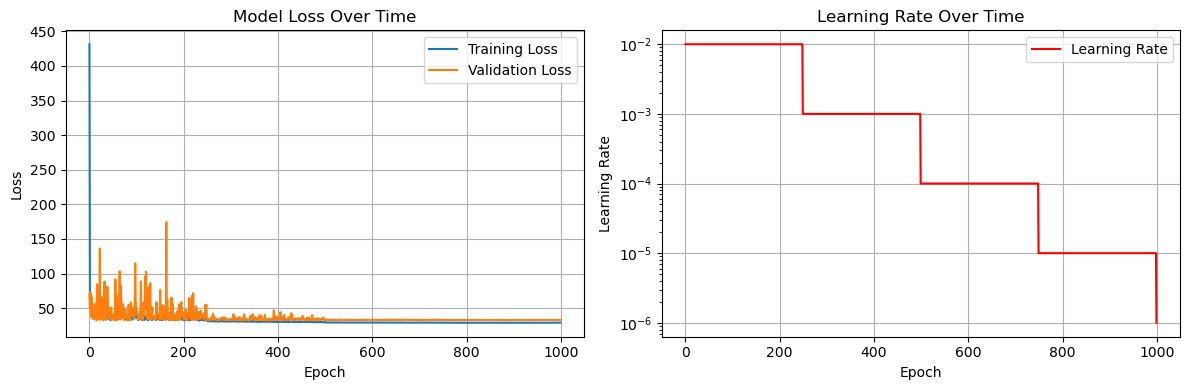

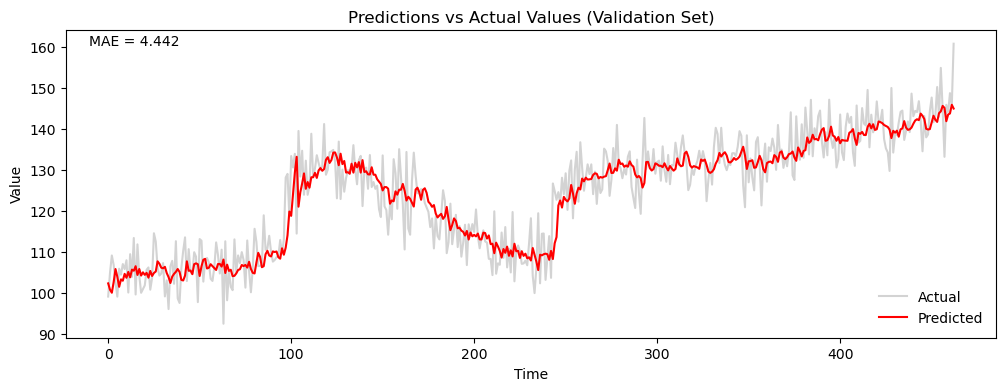

In [26]:
# Initialize model
model = TimeSeriesMLP(window_size - 1)
model.to(device)

# Set up training
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-2)
scheduler = lr_scheduler.StepLR(optimizer, step_size=250, gamma=.1)

# Train the model
train_losses, val_losses, learning_rates = train(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    epochs=1000,
    scheduler=scheduler,
)

# Analyse training
plot_training(train_losses, val_losses, learning_rates)

# predict
predictions, targets = predict(model, val_loader)
plot_prediction(predictions, targets)

#### Hyperparameter tuning

In [ ]:
# !pip install optuna

In [21]:
def create_model(trial):
    """Create model with hyperparameters suggested by Optuna"""
    # Define hyperparameters to search
    n_hidden = trial.suggest_int('n_hidden', 5, 50)  # Number of hidden units
    n_layers = trial.suggest_int('n_layers', 1, 3)   # Number of hidden layers
    lr = trial.suggest_float('lr', 1e-4, 1e-1, log=True)  # Learning rate
    dropout = trial.suggest_float('dropout', 0.0, 0.5)    # Dropout rate

    # Create model
    class TimeSeriesMLP(nn.Module):
        def __init__(self):
            super(TimeSeriesMLP, self).__init__()
            layers = []
            in_features = window_size - 1
            # Input layer
            for i in range(n_layers):
                layers.append(nn.Linear(in_features, n_hidden))
                layers.append(nn.ReLU())
                layers.append(nn.Dropout(dropout))
                in_features = n_hidden

            # Output layer
            layers.append(nn.Linear(n_hidden, 1))

            self.network = nn.Sequential(*layers)

        def forward(self, x):
            return self.network(x)

    return TimeSeriesMLP(), lr

def objective(trial):
    """Optuna objective function to minimize"""
    # Create model and optimizer with trial hyperparameters
    model, lr = create_model(trial)
    optimizer = optim.Adam(model.parameters(), lr=lr)

    # Train the model
    model.to(device)

    for epoch in range(20):  # Reduced epochs for faster tuning
        # Training
        model.train()
        train_loss = 0
        for X, y in train_loader:
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            outputs = model(X)
            loss = nn.MSELoss()(outputs, y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        # Validation
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for X, y in val_loader:
                X, y = X.to(device), y.to(device)
                outputs = model(X)
                val_loss += nn.MSELoss()(outputs, y).item()
        val_loss /= len(val_loader)

        # Report intermediate value for pruning
        trial.report(val_loss, epoch)

        # Handle pruning based on the intermediate value
        if trial.should_prune():
            raise optuna.TrialPruned()

    return val_loss

In [22]:
# Create study and optimize
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)  # Try 50 different hyperparameter combinations

[I 2025-12-12 19:37:09,763] A new study created in memory with name: no-name-bdc506dd-7398-48bc-ab68-7e48ae6583df
[I 2025-12-12 19:37:17,589] Trial 0 finished with value: 63.71110102335612 and parameters: {'n_hidden': 33, 'n_layers': 2, 'lr': 0.0005335823553069421, 'dropout': 0.42363887041054604}. Best is trial 0 with value: 63.71110102335612.
[I 2025-12-12 19:37:19,886] Trial 1 finished with value: 466.18837585449216 and parameters: {'n_hidden': 21, 'n_layers': 2, 'lr': 0.0002665300090713677, 'dropout': 0.3141974688580302}. Best is trial 0 with value: 63.71110102335612.
[I 2025-12-12 19:37:22,528] Trial 2 finished with value: 4848.682926432291 and parameters: {'n_hidden': 6, 'n_layers': 2, 'lr': 0.02820692571116323, 'dropout': 0.2630301044483899}. Best is trial 0 with value: 63.71110102335612.
[I 2025-12-12 19:37:24,769] Trial 3 finished with value: 88.9988187154134 and parameters: {'n_hidden': 40, 'n_layers': 1, 'lr': 0.0067203090060514266, 'dropout': 0.43559672824291584}. Best is tr

In [28]:
# Print results
print("Best trial:")
trial = study.best_trial
print("  Value: ", trial.value)
print("  Params: ")
for key, value in trial.params.items():
    print(f"    {key}: {value}")

# Visualize the optimization results
print("\nPlotting optimization results...")
try:
    # Plot optimization history
    optuna.visualization.plot_optimization_history(study)

    # Plot parameter importance
    optuna.visualization.plot_param_importances(study)

    # Plot parameter relationships
    optuna.visualization.plot_parallel_coordinate(study)
except:
    print("Visualization requires plotly to be installed")

Best trial:
  Value:  33.3217830657959
  Params: 
    n_hidden: 50
    n_layers: 1
    lr: 0.0015285974170219797
    dropout: 0.06221855669903026

Plotting optimization results...
Visualization requires plotly to be installed


In [27]:
# Create final model with best parameters
best_model, best_lr = create_model(trial)
best_model.to(device)
best_optimizer = optim.Adam(best_model.parameters(), lr=best_lr)

print("\nBest model architecture:")
print(best_model)


Best model architecture:
TimeSeriesMLP(
  (network): Sequential(
    (0): Linear(in_features=44, out_features=50, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.06221855669903026, inplace=False)
    (3): Linear(in_features=50, out_features=1, bias=True)
  )
)


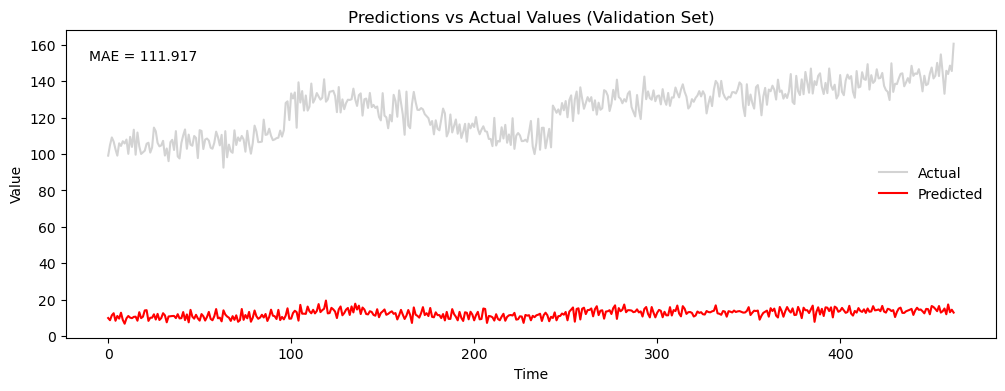

In [26]:
# predict
predictions, targets = predict(best_model, val_loader)
plot_prediction(predictions, targets)